# EDA – Car Purchase Dataset

Exploratory Data Analysis to inform preprocessing and modeling decisions.

## 1. Setup and load

Confirm row count, column names, and data path.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Data/car_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (1000, 5)


,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0


## 2. Data quality

Missing values, duplicates, and User ID uniqueness. Informs: imputation, drop duplicates, drop User ID in pipeline.

In [ ]:
# 2.1 Missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
User ID,0,0.0
Gender,0,0.0
Age,0,0.0
AnnualSalary,0,0.0
Purchased,0,0.0


In [4]:
# 2.2 Duplicates
print('Duplicate rows (any):', df.duplicated().sum())
print('Rows involved in duplicates (keep=False):', df.duplicated(keep=False).sum())

Duplicate rows (any): 0
Rows involved in duplicates (keep=False): 0


In [5]:
# 2.3 User ID uniqueness
print('Unique User IDs:', df['User ID'].nunique())
print('Total rows:', len(df))
print('User ID is unique per row:', df['User ID'].nunique() == len(df))

Unique User IDs: 1000
Total rows: 1000
User ID is unique per row: True


## 3. Target variable (Purchased)

Class balance informs: stratified split, choice of metrics (accuracy vs precision/recall/F1/ROC-AUC).

In [6]:
# Counts and proportions
print(df['Purchased'].value_counts())
print('\nProportions:')
print(df['Purchased'].value_counts(normalize=True))

Purchased
0    598
1    402
Name: count, dtype: int64

Proportions:
Purchased
0    0.598
1    0.402
Name: proportion, dtype: float64


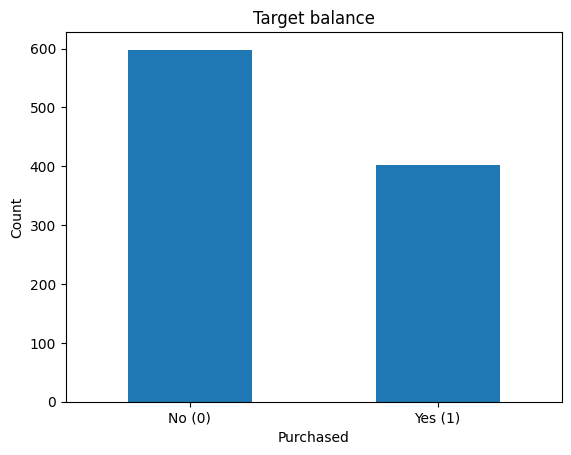

In [7]:
# Bar chart: Purchased (0 vs 1)
df['Purchased'].value_counts().sort_index().plot(kind='bar', xlabel='Purchased', ylabel='Count', title='Target balance')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'], rotation=0)
plt.show()

## 4. Numeric features (Age, AnnualSalary)

Summary stats and distributions inform: scaling (StandardScaler), optional transforms, outlier handling.

In [8]:
# 4.1 Summary statistics
df[['Age', 'AnnualSalary']].describe()

,Age,AnnualSalary
count,1000.000000,1000.000000
mean,40.106000,72689.000000
std,10.707073,34488.341867
min,18.000000,15000.000000
25%,32.000000,46375.000000
50%,40.000000,72000.000000
75%,48.000000,90000.000000
max,63.000000,152500.000000


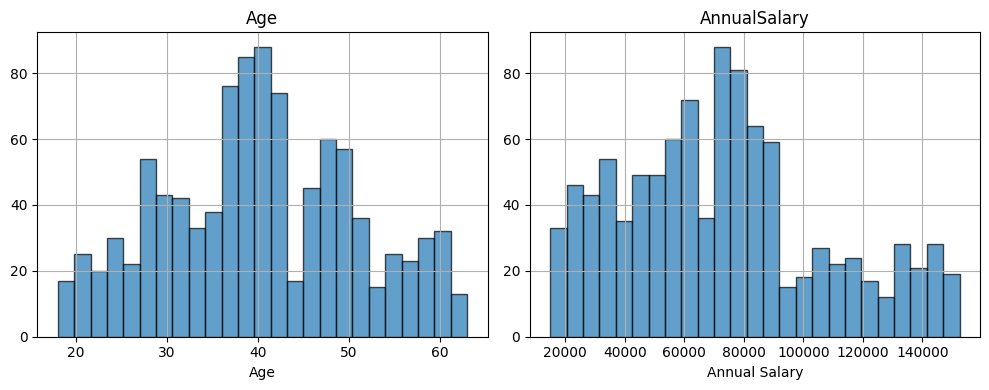

In [9]:
# 4.2 Distributions (histograms)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['Age'].hist(ax=axes[0], bins=25, edgecolor='black', alpha=0.7)
axes[0].set_title('Age')
axes[0].set_xlabel('Age')
df['AnnualSalary'].hist(ax=axes[1], bins=25, edgecolor='black', alpha=0.7)
axes[1].set_title('AnnualSalary')
axes[1].set_xlabel('Annual Salary')
plt.tight_layout()
plt.show()

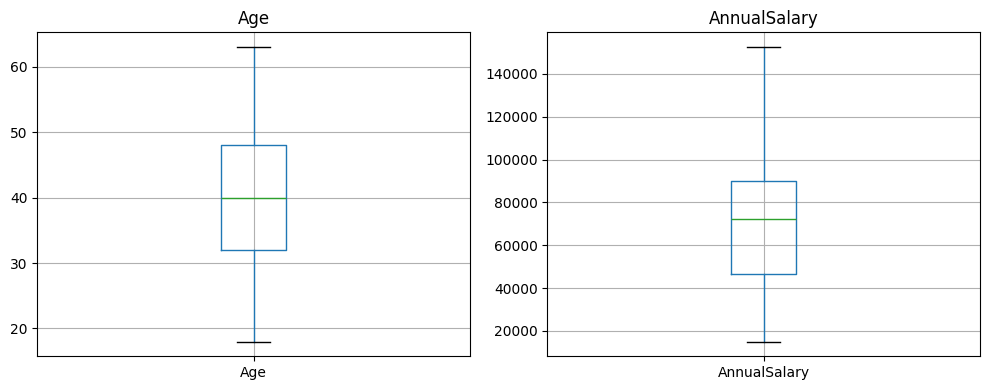

In [10]:
# 4.3 Outliers (box plots)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df.boxplot(column='Age', ax=axes[0])
axes[0].set_title('Age')
df.boxplot(column='AnnualSalary', ax=axes[1])
axes[1].set_title('AnnualSalary')
plt.tight_layout()
plt.show()

## 5. Categorical feature (Gender)

Counts and balance confirm levels (Male/Female) and need for encoding. Gender vs target shows feature usefulness.

In [11]:
# 5.1 Gender counts and proportions
print(df['Gender'].value_counts())
print('\nProportions:')
print(df['Gender'].value_counts(normalize=True))

Gender
Female    516
Male      484
Name: count, dtype: int64

Proportions:
Gender
Female    0.516
Male      0.484
Name: proportion, dtype: float64


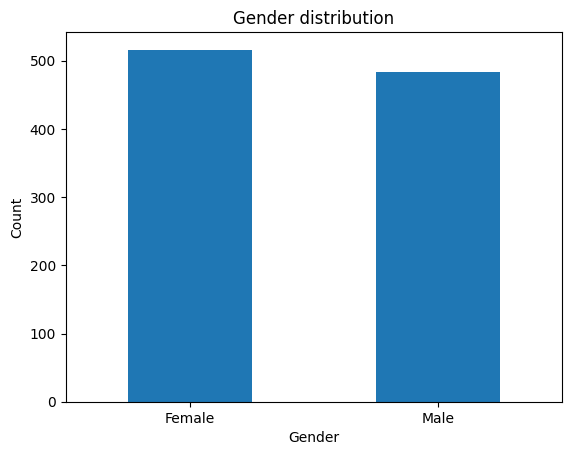

In [12]:
# Bar chart: Gender counts
df['Gender'].value_counts().plot(kind='bar', xlabel='Gender', ylabel='Count', title='Gender distribution')
plt.xticks(rotation=0)
plt.show()

In [13]:
# 5.2 Gender vs target: cross-tab and purchase rate
print(pd.crosstab(df['Gender'], df['Purchased']))
print('\nPurchase rate by Gender:')
print(df.groupby('Gender')['Purchased'].mean())

Purchased    0    1
Gender             
Female     297  219
Male       301  183

Purchase rate by Gender:
Gender
Female    0.424419
Male      0.378099
Name: Purchased, dtype: float64


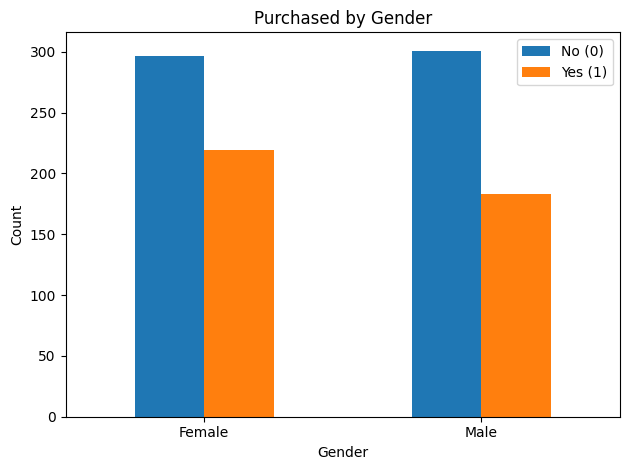

In [14]:
# Grouped bar: Gender x Purchased
pd.crosstab(df['Gender'], df['Purchased']).plot(kind='bar', xlabel='Gender', ylabel='Count', title='Purchased by Gender')
plt.legend(['No (0)', 'Yes (1)'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Relationships (target and features)

Target vs numerics and correlation inform: model type (linear vs non-linear), feature usefulness, multicollinearity.

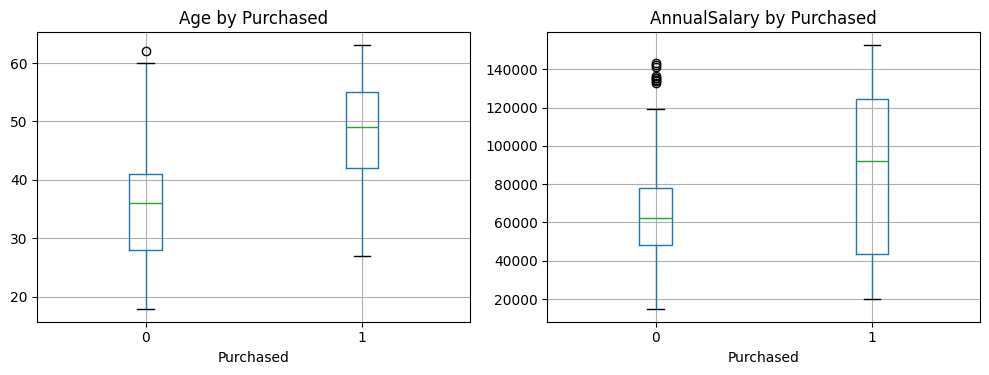

In [15]:
# 6.1 Box plots: Age and AnnualSalary by Purchased
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df.boxplot(column='Age', by='Purchased', ax=axes[0])
axes[0].set_title('Age by Purchased')
axes[0].set_xlabel('Purchased')
plt.suptitle('')
df.boxplot(column='AnnualSalary', by='Purchased', ax=axes[1])
axes[1].set_title('AnnualSalary by Purchased')
axes[1].set_xlabel('Purchased')
plt.suptitle('')
plt.tight_layout()
plt.show()

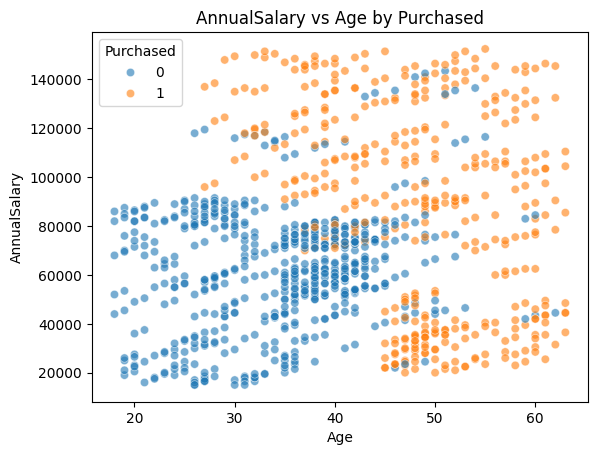

In [16]:
# Scatter: AnnualSalary vs Age, colored by Purchased
sns.scatterplot(data=df, x='Age', y='AnnualSalary', hue='Purchased', alpha=0.6)
plt.title('AnnualSalary vs Age by Purchased')
plt.show()

                   Age  AnnualSalary  Purchased
Age           1.000000      0.166042   0.616036
AnnualSalary  0.166042      1.000000   0.364974
Purchased     0.616036      0.364974   1.000000


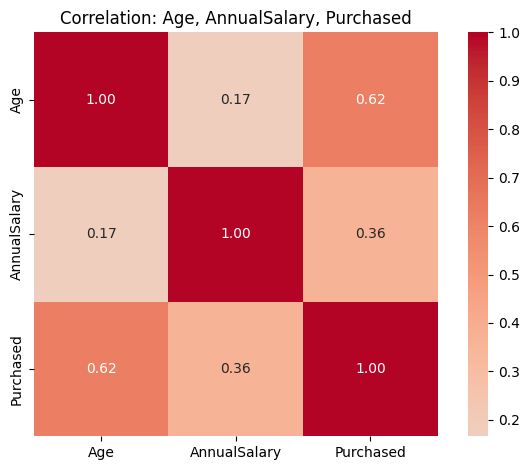

In [17]:
# 6.2 Correlation matrix and heatmap
corr = df[['Age', 'AnnualSalary', 'Purchased']].corr()
print(corr)
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation: Age, AnnualSalary, Purchased')
plt.tight_layout()
plt.show()

## 7. EDA conclusions and next steps

After running all cells above, summarize here and use to update the preprocessing/model plan and `pipeline.py`:

- **Missing**: Yes/No → imputation in preprocessing or not.
- **Duplicates**: Yes/No → drop or not.
- **User ID**: Drop in pipeline (non-predictive).
- **Class balance**: Balanced / slightly imbalanced / imbalanced → use stratified split and choose primary metrics (accuracy vs precision/recall/F1/ROC-AUC).
- **Numerics**: Scale Age and AnnualSalary (e.g. StandardScaler); note any outlier decision (cap/winsorize or leave as-is).
- **Gender**: Encode (e.g. LabelEncoder or OneHotEncoder); confirm levels (Male/Female only).
- **Relationships**: Linear separation or not → baseline model (e.g. logistic regression) vs tree/boosting.